# **Judicial Service Gen AI Chatbot For District Court**

---

## **Introduction**

---

This guide shows you how to build a professional-grade, zero-license-cost FAQ LLM for court services using only three fields—category, question, answer—plus optional SOP/Standards text. The approach is Retrieval-Augmented Generation (RAG) with a pragmatic rule: when a match is very strong, answer directly from the CSV; otherwise, retrieve the best entries and have a small local LLM compose a single, clear paragraph. Every answer cites its category and ends with a short compliance disclaimer.

---

## **Import Library**

---

### **Data Loading**

---

In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from textwrap import fill

In [2]:
# Data loading
faq = pd.read_csv("Data/standar_layanan_combined.csv")
faq.head()

,category,question,answer
0,STANDAR PELAYANAN PENDAFTARAN SURAT KETERANGAN...,Dalam ketentuan layanan standar pelayanan pend...,Dokumen yang harus disiapkan mencakup surat pe...
1,STANDAR PELAYANAN PENDAFTARAN SURAT KETERANGAN...,Dalam ketentuan layanan standar pelayanan pend...,Dokumen yang harus disiapkan mencakup surat pe...
2,STANDAR PELAYANAN PENDAFTARAN SURAT KETERANGAN...,Dalam ketentuan layanan standar pelayanan pend...,Dokumen yang harus disiapkan mencakup surat pe...
3,STANDAR PELAYANAN PENDAFTARAN SURAT KETERANGAN...,Dalam ketentuan layanan standar pelayanan pend...,Dokumen yang harus disiapkan mencakup surat pe...
4,STANDAR PELAYANAN PENDAFTARAN SURAT KETERANGAN...,Dalam ketentuan layanan standar pelayanan pend...,Dokumen yang harus disiapkan mencakup surat pe...


In [3]:
# Display basic info about the dataset
faq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  6000 non-null   object
 1   question  6000 non-null   object
 2   answer    6000 non-null   object
dtypes: object(3)
memory usage: 140.8+ KB


**Insight:**

The dataset consists of FAQs obtained from court service standards and SOPs. The 1,000 FAQs obtained have no missing values, so they can be used as a guideline for the Hiblu Chatbot LLM modeling.The dataset consists of FAQs obtained from court service standards and SOPs. The 1,000 FAQs obtained have no missing values, so they can be used as a guideline for the Hiblu Chatbot LLM modeling.

---

### **Word Cloud & Exploratory Data Analysis**

---

#### **Most Frequent Question Words**

---

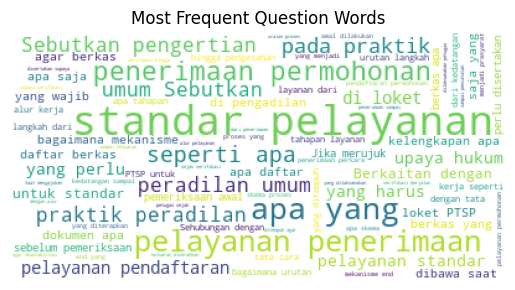

In [4]:
# Make  word cloud for questions
text = faq['question'].values
wordcloud = WordCloud(background_color="white").generate(" ".join(text))

# Plot word cloud.
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Most Frequent Question Words')
plt.show()

#### **Most Frequent Answer Words**

---

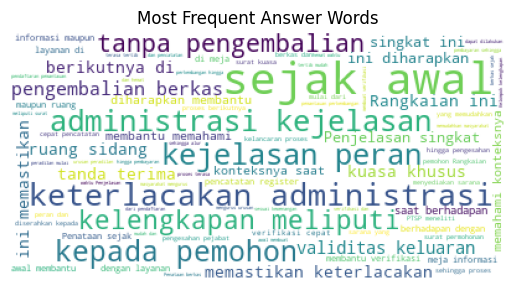

In [5]:
# Make  word cloud for answers
text = faq['answer'].values
wordcloud = WordCloud(background_color="white").generate(" ".join(text))

# Plot word cloud.
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Most Frequent Answer Words')
plt.show()

#### **Word Count**

---

In [6]:
# Count category frequencies
faq['question'] = faq['question'].fillna('').astype(str).str.strip()
faq['Question_word_count'] = faq['question'].str.split().str.len()

# Show min, max, mean (rounded to 2 decimals)
print('Question Column:')
print('Minimum word count:', int(faq['Question_word_count'].min()))
print('Maximum word count:', int(faq['Question_word_count'].max()))
print('Average word count:', round(faq['Question_word_count'].mean(), 2))


Question Column:
Minimum word count: 5
Maximum word count: 29
Average word count: 16.42


In [7]:
# Count category frequencies
faq['answer'] = faq['answer'].fillna('').astype(str).str.strip()
faq['Question_word_count'] = faq['answer'].str.split().str.len()

# Tampilkan min, max, mean (dibulatkan 2 desimal)
print('Question Column:')
print('Minimum word count:', int(faq['Question_word_count'].min()))
print('Maximum word count:', int(faq['Question_word_count'].max()))
print('Average word count:', round(faq['Question_word_count'].mean(), 2))


Question Column:
Minimum word count: 9
Maximum word count: 118
Average word count: 50.76


C:\Users\user\AppData\Local\Temp\ipykernel_16664\1698979065.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(counts))
C:\Users\user\AppData\Local\Temp\ipykernel_16664\1698979065.py:27: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


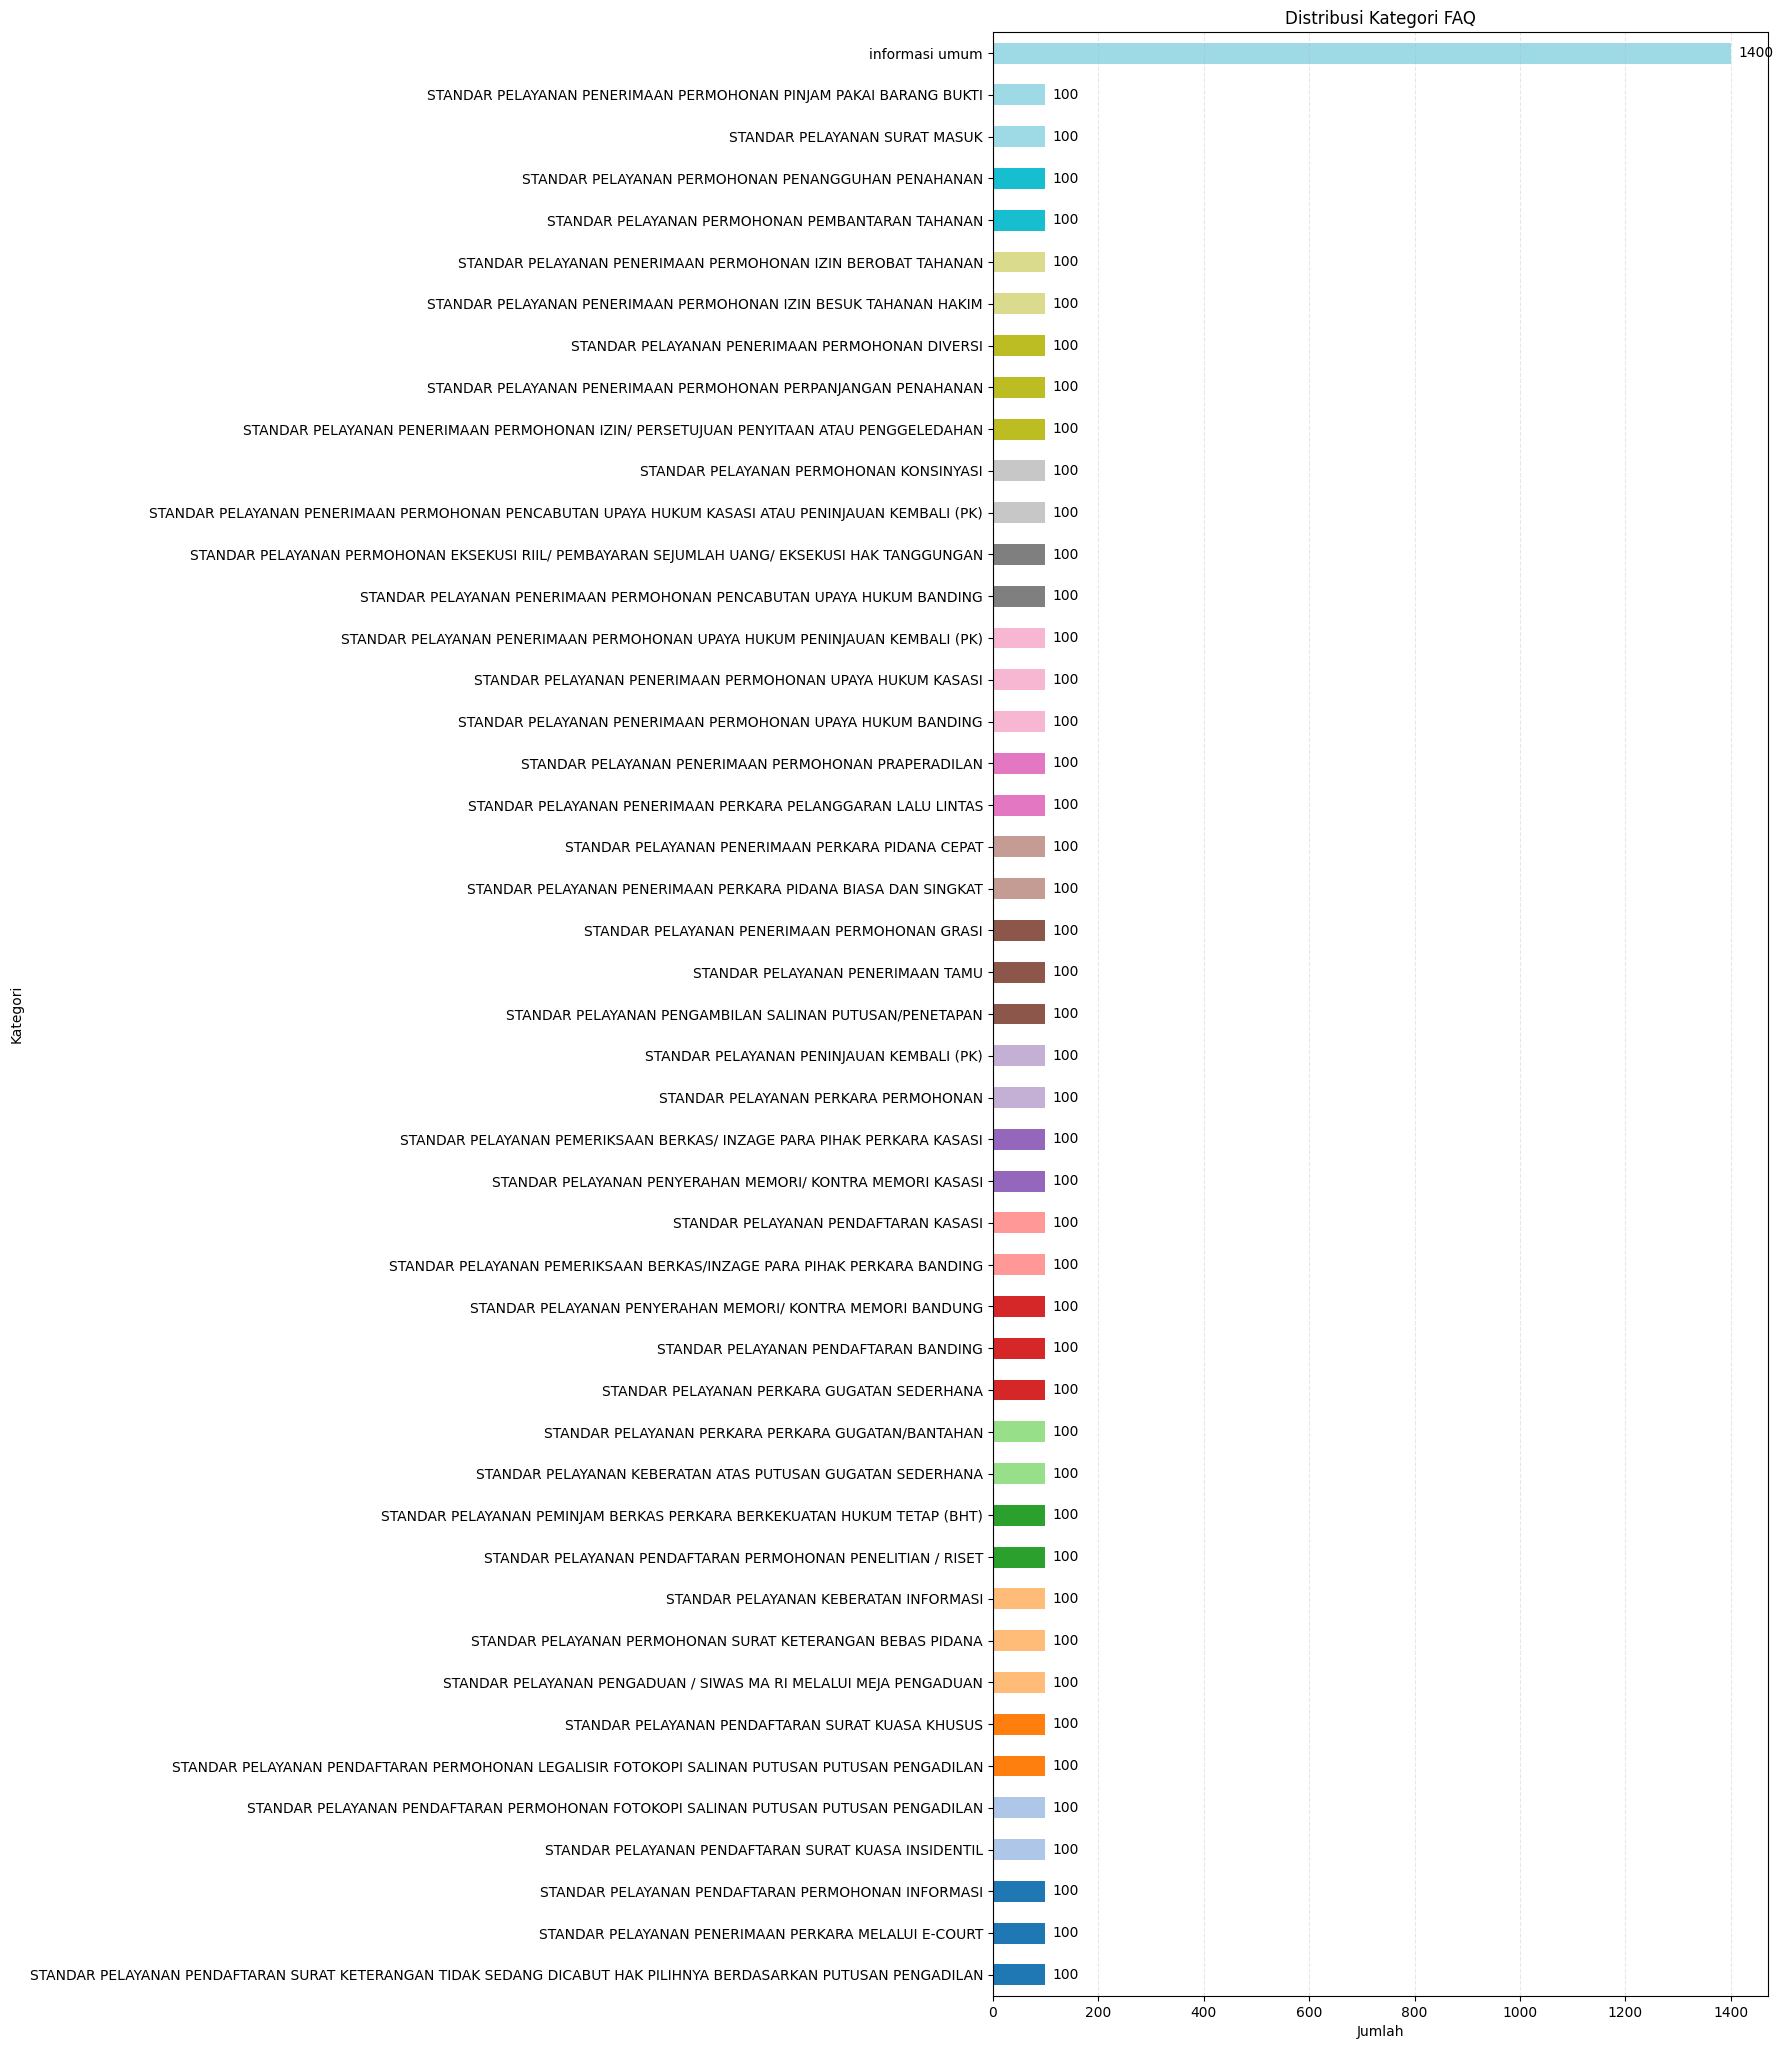

In [8]:
# Count category frequencies
counts = faq['category'].value_counts().sort_values(ascending=True)

# Unique colors for each bar
cmap = plt.cm.get_cmap('tab20', len(counts))
colors = [cmap(i) for i in range(len(counts))]

# Plot horizontal bar chart
ax = counts.plot(kind='barh', color=colors, edgecolor='none', figsize=(10, 0.5*len(counts)+2))

# Format y-tick labels with wrapping
ax.set_title('Distribusi Kategori FAQ')
ax.set_xlabel('Jumlah')
ax.set_ylabel('Kategori')

# Wrap y-tick labels
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

# Add data labels to each bar
for p in ax.patches:
    w = p.get_width()
    ax.text(w + max(counts.max()*0.01, 0.5),
            p.get_y() + p.get_height()/2,
            f'{int(w)}', va='center')

# Show plot
plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_16664\3496499712.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(plot)-1, 1))


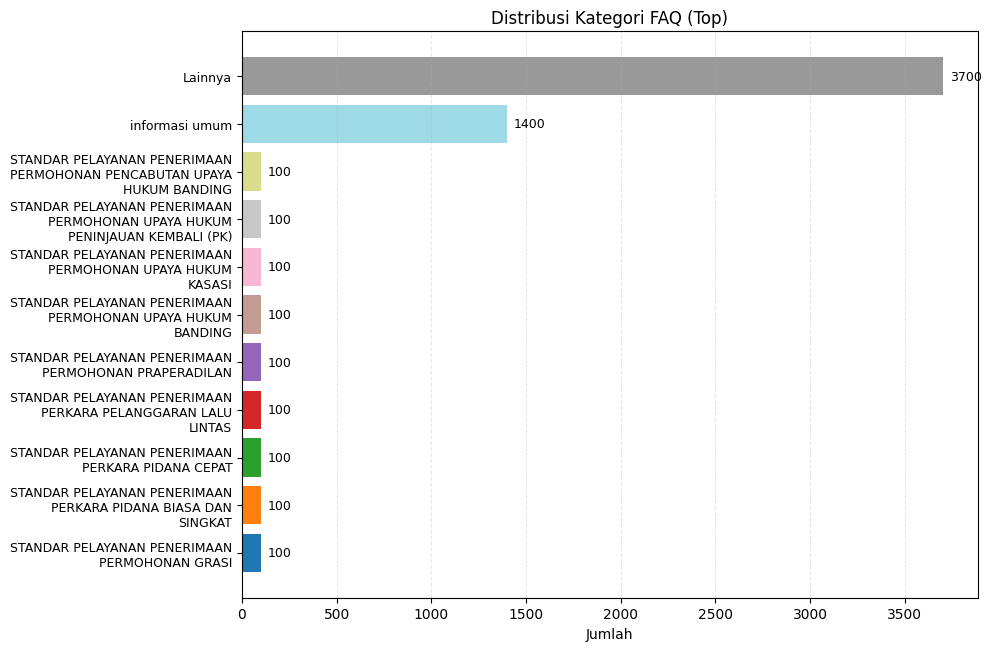

In [9]:
# Count category frequencies
counts = faq['category'].value_counts()

# Parameters
TOP_N = 10        # Show top N categories
WRAP = 28         # Max characters per line in labels
# ----------------------------------

top = counts.head(TOP_N)
sisa = counts.iloc[TOP_N:].sum()

plot = top.copy()
if sisa > 0:
    plot.loc['Lainnya'] = sisa

# Sort so "Lainnya" is at the bottom
if 'Lainnya' in plot.index:
    no_other = plot.drop('Lainnya').sort_values(ascending=True)
    plot = pd.concat([no_other, plot[['Lainnya']]])
else:
    plot = plot.sort_values(ascending=True)

# unique colors for each bar
cmap = plt.cm.get_cmap('tab20', max(len(plot)-1, 1))
colors = [cmap(i) for i in range(len(plot))]
if 'Lainnya' in plot.index:
    colors[-1] = (0.6, 0.6, 0.6, 1.0)  # abu-abu untuk "Lainnya"

# Wrap labels
labels_wrapped = [fill(lbl, width=WRAP) for lbl in plot.index]

fig, ax = plt.subplots(figsize=(10, 0.42*len(plot)+2))
ax.barh(range(len(plot)), plot.values, color=colors)
ax.set_yticks(range(len(plot)))
ax.set_yticklabels(labels_wrapped, fontsize=9)
ax.set_title('Distribusi Kategori FAQ (Top)')
ax.set_xlabel('Jumlah')
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

# Show values on bars
for i, v in enumerate(plot.values):
    ax.text(v + max(plot.max()*0.01, 0.5), i, f'{int(v)}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
faq["category"].value_counts()

category
informasi umum                                                                                                     1400
STANDAR PELAYANAN PENERIMAAN PERMOHONAN GRASI                                                                       100
STANDAR PELAYANAN PENERIMAAN PERKARA PIDANA BIASA DAN SINGKAT                                                       100
STANDAR PELAYANAN PENERIMAAN PERKARA PIDANA CEPAT                                                                   100
STANDAR PELAYANAN PENERIMAAN PERKARA PELANGGARAN LALU LINTAS                                                        100
STANDAR PELAYANAN PENERIMAAN PERMOHONAN PRAPERADILAN                                                                100
STANDAR PELAYANAN PENERIMAAN PERMOHONAN UPAYA HUKUM BANDING                                                         100
STANDAR PELAYANAN PENERIMAAN PERMOHONAN UPAYA HUKUM KASASI                                                          100
STANDAR PELAYANAN PENERIMAAN PE